# 配套实践 06-01：从 RGB-D 图像生成目标点云

本练习对应基础篇第 06 章。我们生成一幅带深度的人工桌面图像，先反投影单个像素，再把目标掩码中的全部像素转换为三维点云。依赖：NumPy、Matplotlib；CPU 即可运行。

<a href="https://qi-robotics.github.io/robot-world-model-tutorial/basics/06-spatial-geometry/" target="_blank">返回课程正文</a>

In [1]:
import numpy as np  # 生成 RGB-D 数据并执行矩阵计算
import matplotlib.pyplot as plt  # 显示彩色图、深度图与三维点云
plt.rcParams["figure.dpi"] = 120  # 提高笔记本图像清晰度

## 1. 定义相机与人工场景

深度值约定为沿相机 z 轴的距离，单位为米。目标杯子比桌面更靠近相机，因此其深度更小。

In [2]:
height, width = 72, 96  # 定义人工 RGB-D 图像的高和宽
fx, fy = 90.0, 92.0  # 定义水平和垂直像素焦距
cx, cy = (width - 1) / 2.0, (height - 1) / 2.0  # 把主点放在图像中心
grid_v, grid_u = np.mgrid[0:height, 0:width]  # 生成每个深度像素的二维坐标
rgb = np.ones((height, width, 3), dtype=np.float64) * np.array([0.68, 0.62, 0.50])  # 创建棕色桌面图像
depth = np.full((height, width), 1.10, dtype=np.float64)  # 让桌面背景位于相机前方一米一
cup_mask = (grid_u - 59.0) ** 2 + (grid_v - 31.0) ** 2 <= 9.0 ** 2  # 定义圆形杯子像素掩码
rgb[cup_mask] = np.array([0.92, 0.08, 0.08])  # 把杯子区域涂成红色
depth[cup_mask] = 0.78 + 0.01 * (grid_v[cup_mask] - 31.0) / 9.0  # 为杯子表面加入轻微深度倾斜
depth[30:33, 57:61] = np.nan  # 模拟反光表面造成的少量无效深度
assert rgb.shape == (height, width, 3)  # 检查 RGB 图像形状
assert depth.shape == (height, width)  # 检查深度图形状

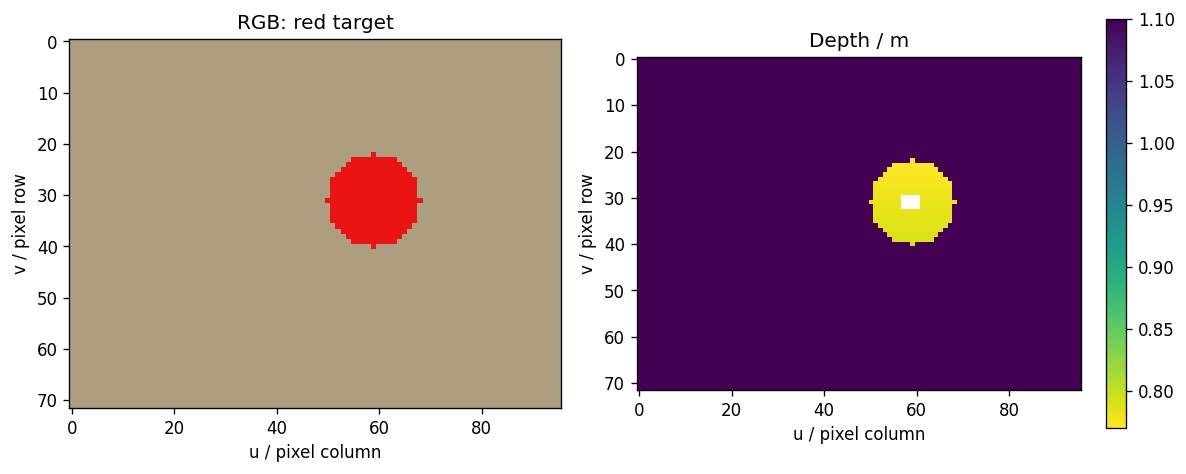

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 创建 RGB 与深度的并排画布
axes[0].imshow(rgb)  # 显示人工彩色图像
axes[0].set_title("RGB: red target")  # 说明颜色含义
depth_view = axes[1].imshow(depth, cmap="viridis_r")  # 用颜色显示每个像素的 z 深度
axes[1].set_title("Depth / m")  # 标明深度单位为米
fig.colorbar(depth_view, ax=axes[1], fraction=0.046)  # 添加深度颜色刻度
for axis in axes:  # 为两幅图统一标注像素坐标
    axis.set_xlabel("u / pixel column")  # 标出水平像素坐标
    axis.set_ylabel("v / pixel row")  # 标出垂直像素坐标
plt.tight_layout()  # 调整子图避免标签重叠
plt.show()  # 显示 RGB-D 输入

**怎样理解上一结果：** 左图只给出目标位于哪些像素，右图才补充每个像素沿相机 z 轴的距离。杯子区域颜色不同是因为它比桌面更靠近相机；中央黑洞对应无效深度，后续不能把它当作零距离。

## 2. 从一个像素到一个三维点

像素提供射线方向，深度在射线上确定位置。下列函数严格对应正文反投影公式。

In [4]:
def backproject_pixel(u, v, z, intrinsics):  # 把像素和 z 深度转换为相机坐标点
    local_fx, local_fy, local_cx, local_cy = intrinsics  # 解包相机内参并保留单位约定
    x = (u - local_cx) * z / local_fx  # 由水平像素偏移恢复相机 x 坐标
    y = (v - local_cy) * z / local_fy  # 由垂直像素偏移恢复相机 y 坐标
    return np.array([x, y, z], dtype=np.float64)  # 返回单位为米的三维点
sample_u, sample_v = 54, 31  # 选择红色杯子内部且避开深度空洞的有效像素
sample_point = backproject_pixel(sample_u, sample_v, depth[sample_v, sample_u], (fx, fy, cx, cy))  # 反投影示例像素
print(f"像素 ({sample_u}, {sample_v}) -> 相机坐标 {sample_point.round(4)} m")  # 报告像素与三维点的对应
reprojected_u = fx * sample_point[0] / sample_point[2] + cx  # 把三维点重新投影回水平像素
reprojected_v = fy * sample_point[1] / sample_point[2] + cy  # 把三维点重新投影回垂直像素
assert np.allclose([reprojected_u, reprojected_v], [sample_u, sample_v])  # 验证投影和反投影互相一致

像素 (54, 31) -> 相机坐标 [ 0.0563 -0.0382  0.78  ] m


**怎样理解上一结果：** 输出的三个数依次是相机坐标中的 $X_C$、$Y_C$ 和 $Z_C$，单位统一为米。重新投影回原像素的断言通过，说明当前内参、坐标顺序和反投影公式彼此一致；它不能证明真实相机标定一定正确。

## 3. 反投影目标掩码中的全部有效像素

只对目标掩码反投影，可以得到目标点云；无效深度必须先排除。

In [5]:
valid_mask = cup_mask & np.isfinite(depth) & (depth > 0.0)  # 同时要求属于目标且深度有效
valid_u = grid_u[valid_mask].astype(np.float64)  # 取出所有有效目标像素的列坐标
valid_v = grid_v[valid_mask].astype(np.float64)  # 取出所有有效目标像素的行坐标
valid_z = depth[valid_mask]  # 取出每个目标像素的 z 深度
valid_x = (valid_u - cx) * valid_z / fx  # 向量化恢复所有点的 x 坐标
valid_y = (valid_v - cy) * valid_z / fy  # 向量化恢复所有点的 y 坐标
point_cloud = np.stack([valid_x, valid_y, valid_z], axis=1)  # 按 N×3 组织目标点云
point_colors = rgb[valid_mask]  # 为每个三维点保留对应 RGB 颜色
assert point_cloud.ndim == 2 and point_cloud.shape[1] == 3  # 检查点云接口为 N×3
assert np.isfinite(point_cloud).all()  # 检查无效深度没有进入点云
print(f"有效目标点数: {len(point_cloud)}，点云形状: {point_cloud.shape}")  # 报告点云规模与形状

有效目标点数: 241，点云形状: (241, 3)


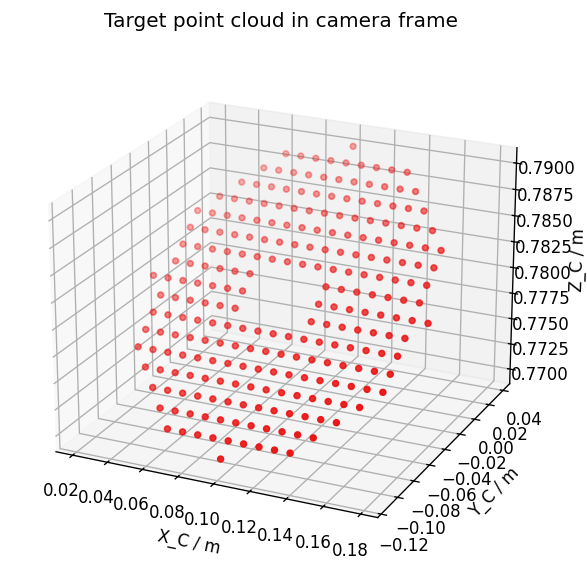

In [6]:
figure = plt.figure(figsize=(7, 5))  # 创建三维点云画布
axis = figure.add_subplot(111, projection="3d")  # 添加三维坐标轴
axis.scatter(point_cloud[:, 0], point_cloud[:, 1], point_cloud[:, 2], c=point_colors, s=12)  # 按原始颜色绘制目标点云
axis.set_xlabel("X_C / m")  # 标注相机水平坐标与单位
axis.set_ylabel("Y_C / m")  # 标注相机垂直坐标与单位
axis.set_zlabel("Z_C / m")  # 标注相机深度坐标与单位
axis.set_title("Target point cloud in camera frame")  # 说明点云所属坐标系
axis.view_init(elev=22, azim=-65)  # 选择便于观察表面倾斜的视角
plt.tight_layout()  # 减少图形边缘留白
plt.show()  # 显示目标三维点云

**怎样理解结果：** 有效点数小于圆形掩码的总像素数，是因为无效深度已经被排除。三维图中的点形成一小片倾斜表面，来源是人工深度中加入的轻微纵向变化；坐标轴标签中的下标 $C$ 表明这些点仍在相机坐标系，尚不能直接作为机械臂基座目标。

## 结论与练习

点云仍只是当前视角可见的杯子表面，不是完整杯子模型。尝试把深度整体增加 0.2 米，观察点云的 z 坐标与横向范围如何变化；再把 `fx` 减半，解释为什么相同像素偏移会对应更大的横向坐标。